<a href="https://colab.research.google.com/github/OnMamiow/MyPortfolio.github.io/blob/main/%E0%B8%AA%E0%B8%B3%E0%B9%80%E0%B8%99%E0%B8%B2%E0%B8%82%E0%B8%AD%E0%B8%87_Customer_Segmentation_with_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import missingno as msno
from IPython.display import display
from sklearn.preprocessing import OrdinalEncoder
sns.set()
import warnings
warnings.filterwarnings('ignore')

# **Import Data**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
train_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
train_data

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64
Segmentation
D    28.111056
A    24.442241
C    24.417452
B    23.029251
Name: count, dtype: float64


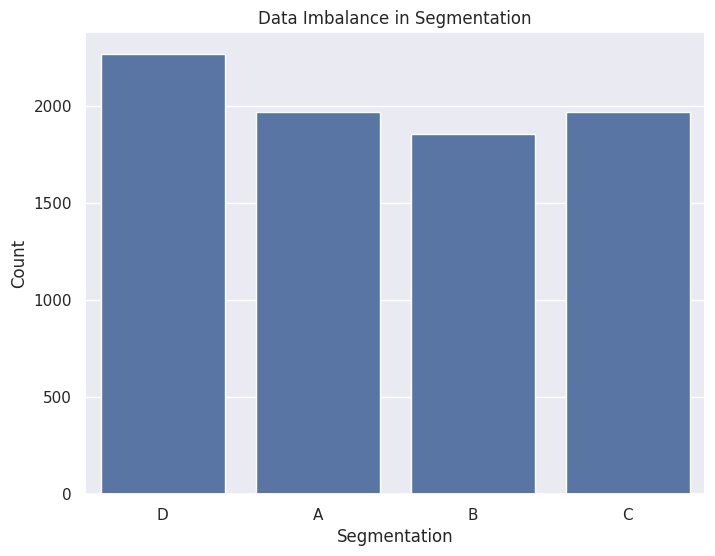

In [ ]:
# prompt: check data imbalance in column Segmentation

import matplotlib.pyplot as plt
# Check for data imbalance in the 'Segmentation' column
segmentation_counts = train_data['Segmentation'].value_counts()
print(segmentation_counts)

# Calculate and print the percentage of each segmentation value
segmentation_percentages = (segmentation_counts / len(train_data)) * 100
print(segmentation_percentages)

# Visualize the data imbalance using a bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x='Segmentation', data=train_data)
plt.title('Data Imbalance in Segmentation')
plt.xlabel('Segmentation')
plt.ylabel('Count')
plt.show()


In [ ]:
train = train_data[['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size','Var_1']]
train

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6
...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6


In [ ]:
train_data['Segmentation'].value_counts().sort_values(ascending=False)

,count
Segmentation,
D,2268
A,1972
C,1970
B,1858


In [ ]:
print(train_data['Segmentation'].unique())

['D' 'A' 'B' 'C']


# **Exploratory Data Analysis**

In [ ]:
train.info() #showing about infomation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 630.4+ KB


In [ ]:
train.isna().sum() #checking missing values

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
# prompt: fill missing data

# Fill missing values in 'Ever_Married' with the mode
train['Ever_Married'].fillna(train['Ever_Married'].mode()[0], inplace=True)

# Fill missing values in 'Graduated' with the mode
train['Graduated'].fillna(train['Graduated'].mode()[0], inplace=True)

# Fill missing values in 'Profession' with the mode
train['Profession'].fillna(train['Profession'].mode()[0], inplace=True)

# Fill missing values in 'Work_Experience' with the median
train['Work_Experience'].fillna(train['Work_Experience'].median(), inplace=True)

# Fill missing values in 'Family_Size' with the median
train['Family_Size'].fillna(train['Family_Size'].median(), inplace=True)

# Fill missing values in 'Var_1' with the mode
train['Var_1'].fillna(train['Var_1'].mode()[0], inplace=True)


In [ ]:
train.isna().sum() #checking missing values

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


In [ ]:
train.head(20)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6


In [ ]:
data  = train.drop('ID',axis=1) # we will drop ID first

In [ ]:
data.info() #new data without ID

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     8068 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        8068 non-null   object 
 4   Profession       8068 non-null   object 
 5   Work_Experience  8068 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      8068 non-null   float64
 8   Var_1            8068 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 567.4+ KB


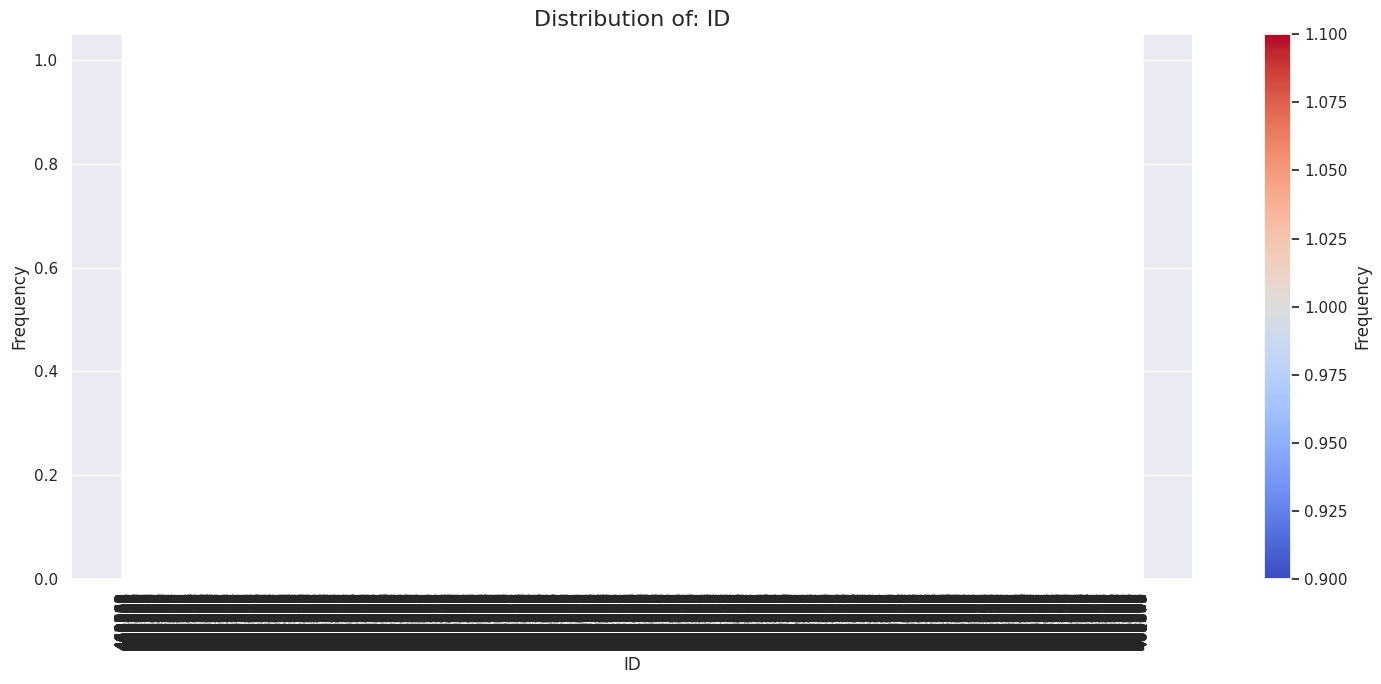

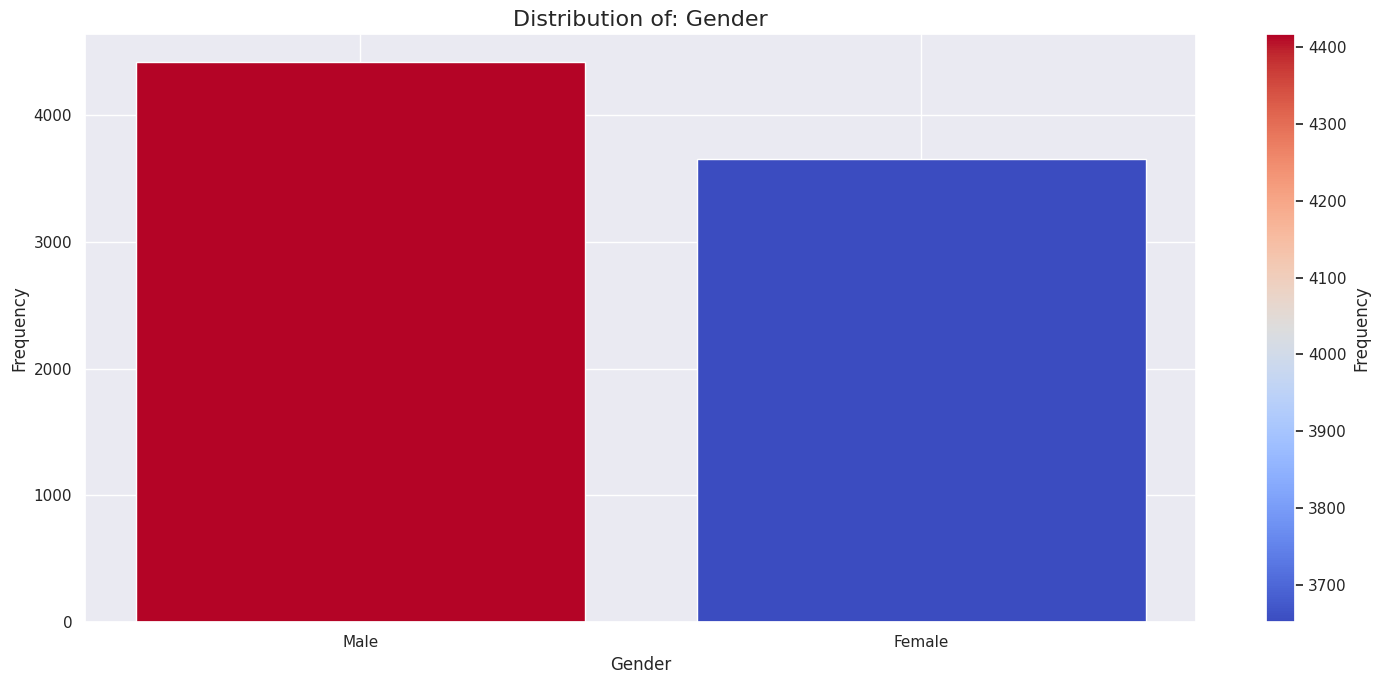

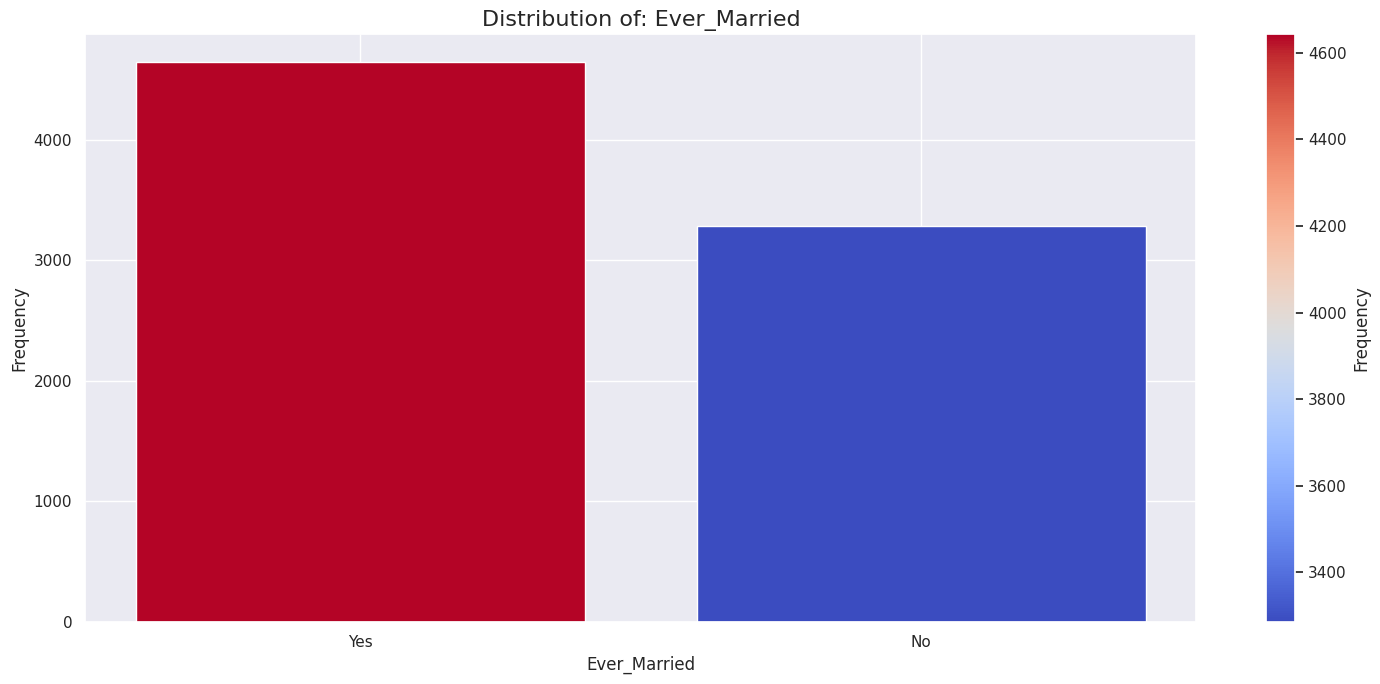

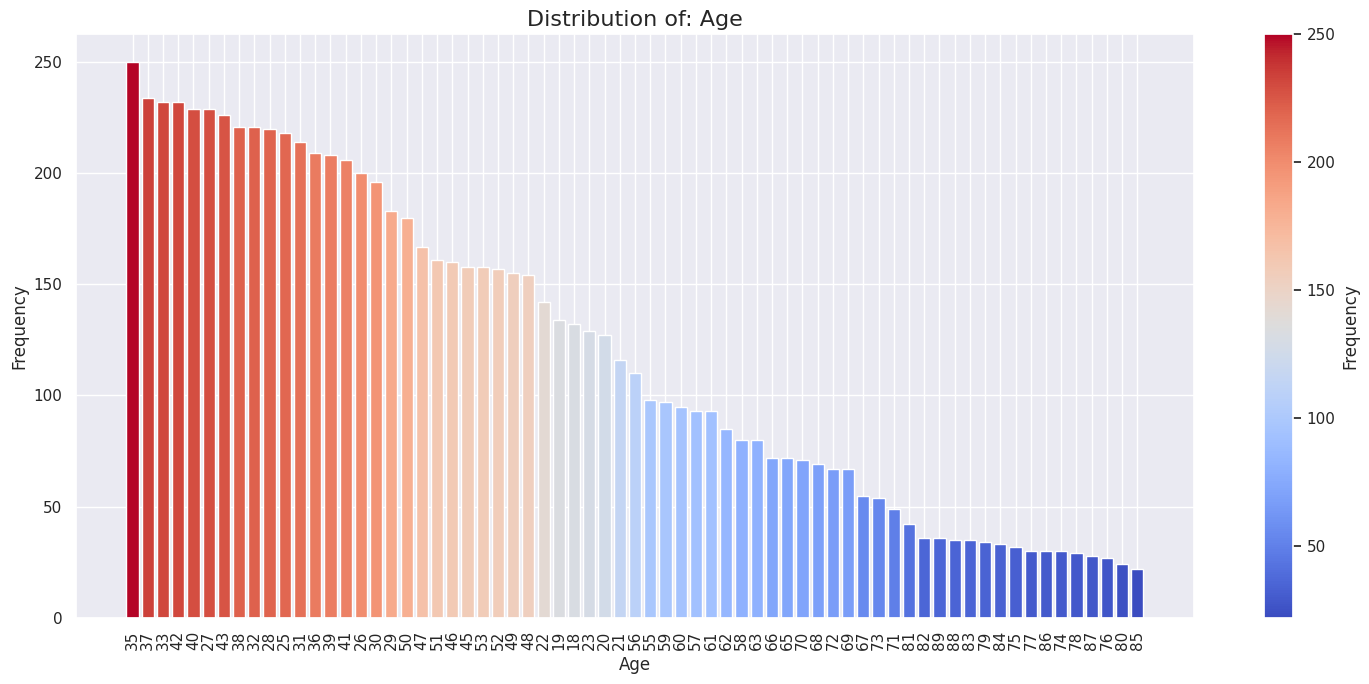

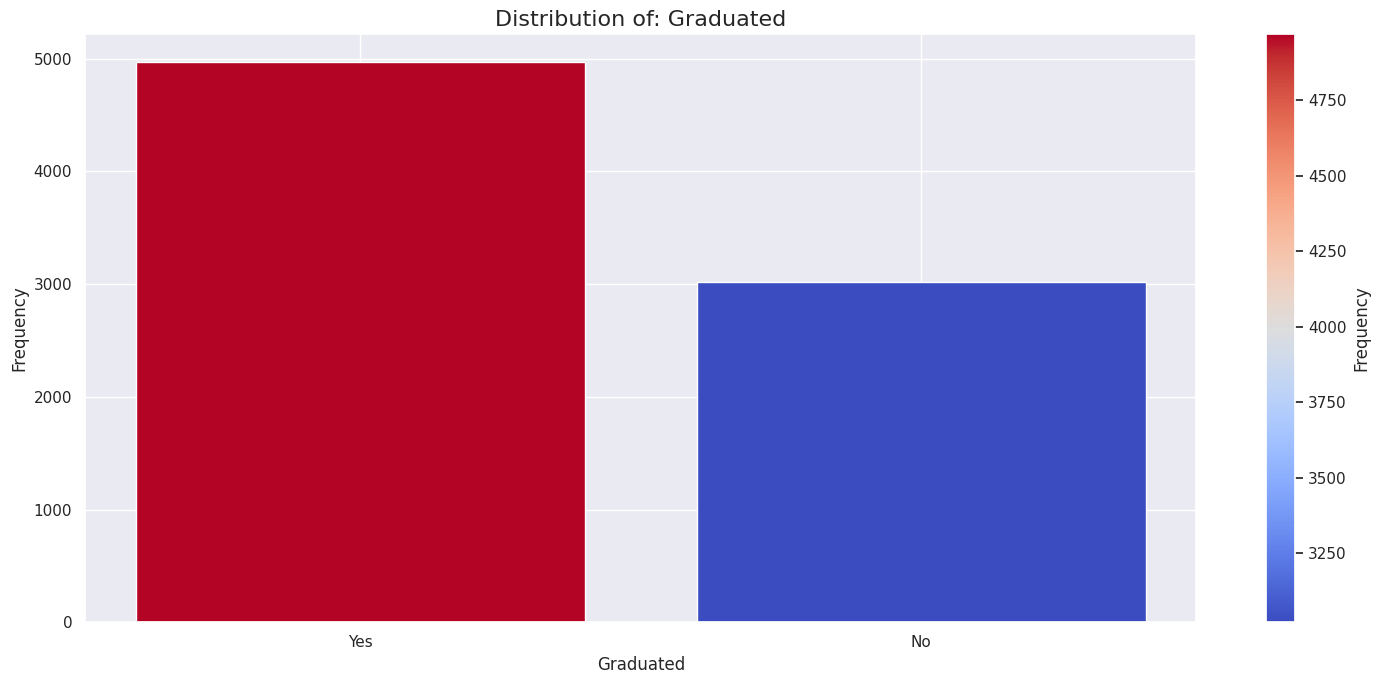

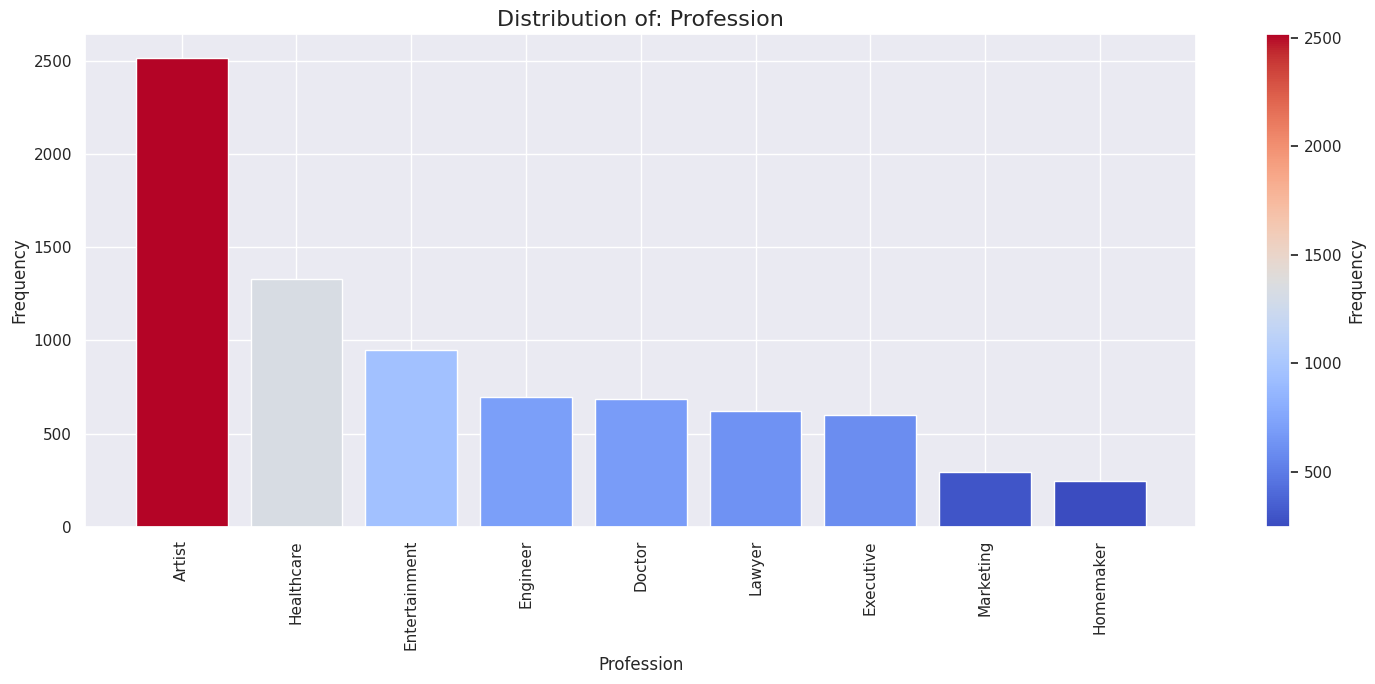

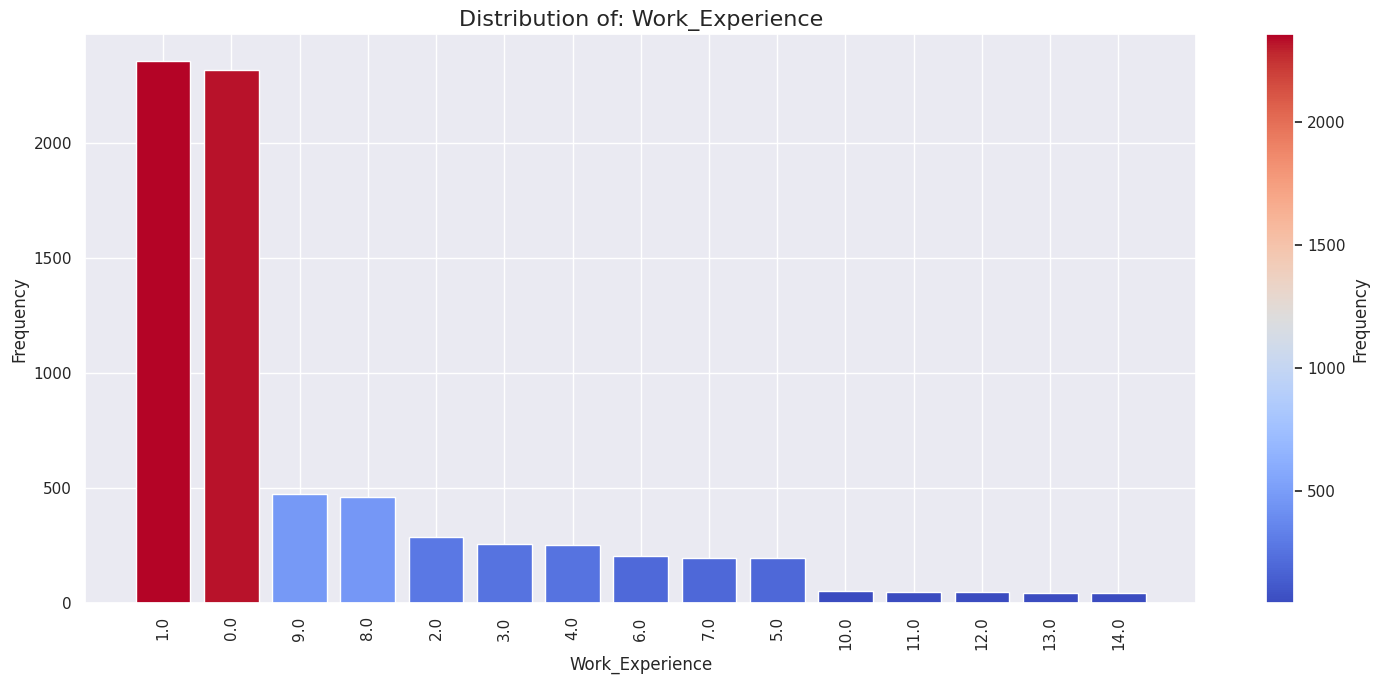

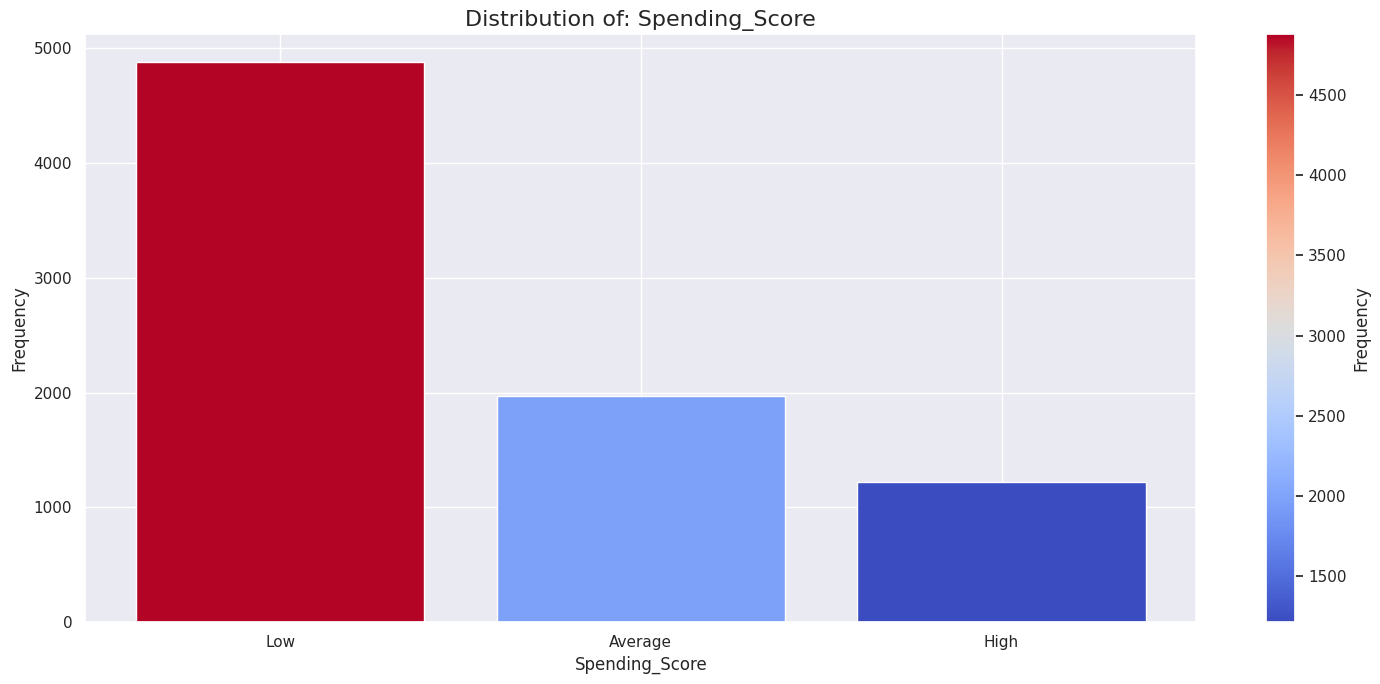

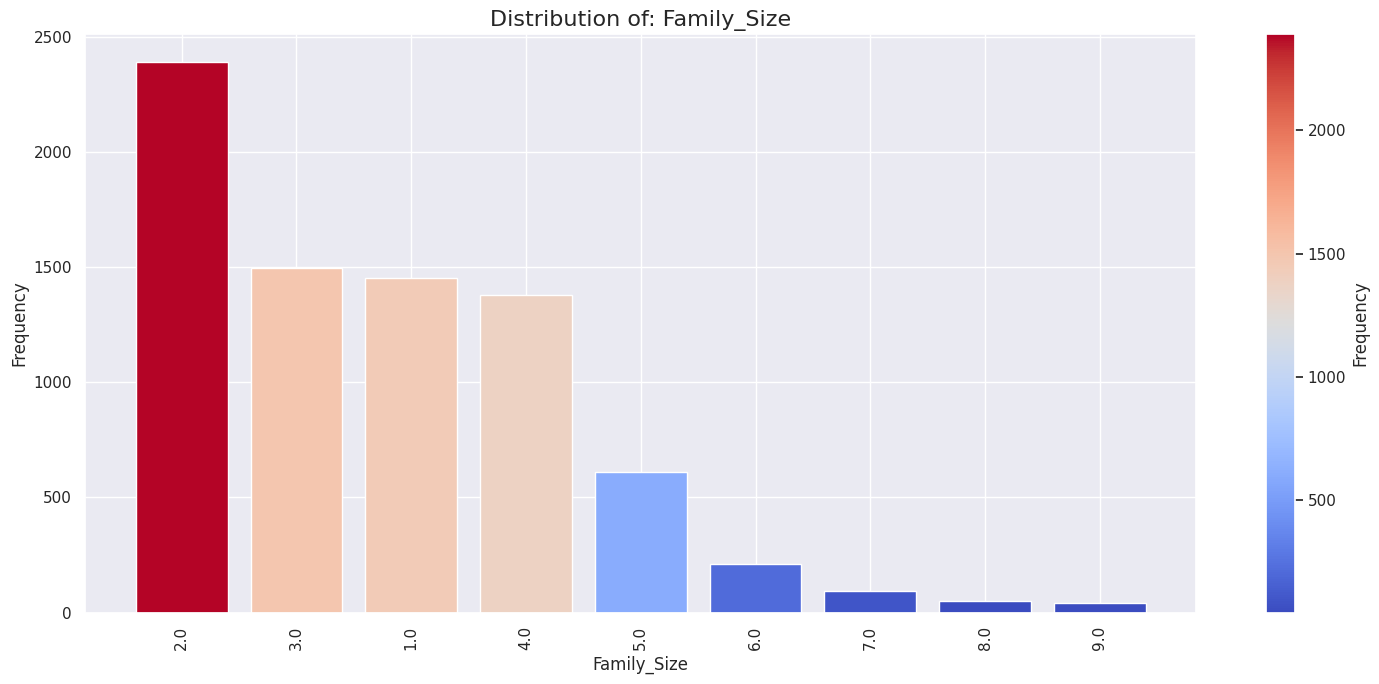

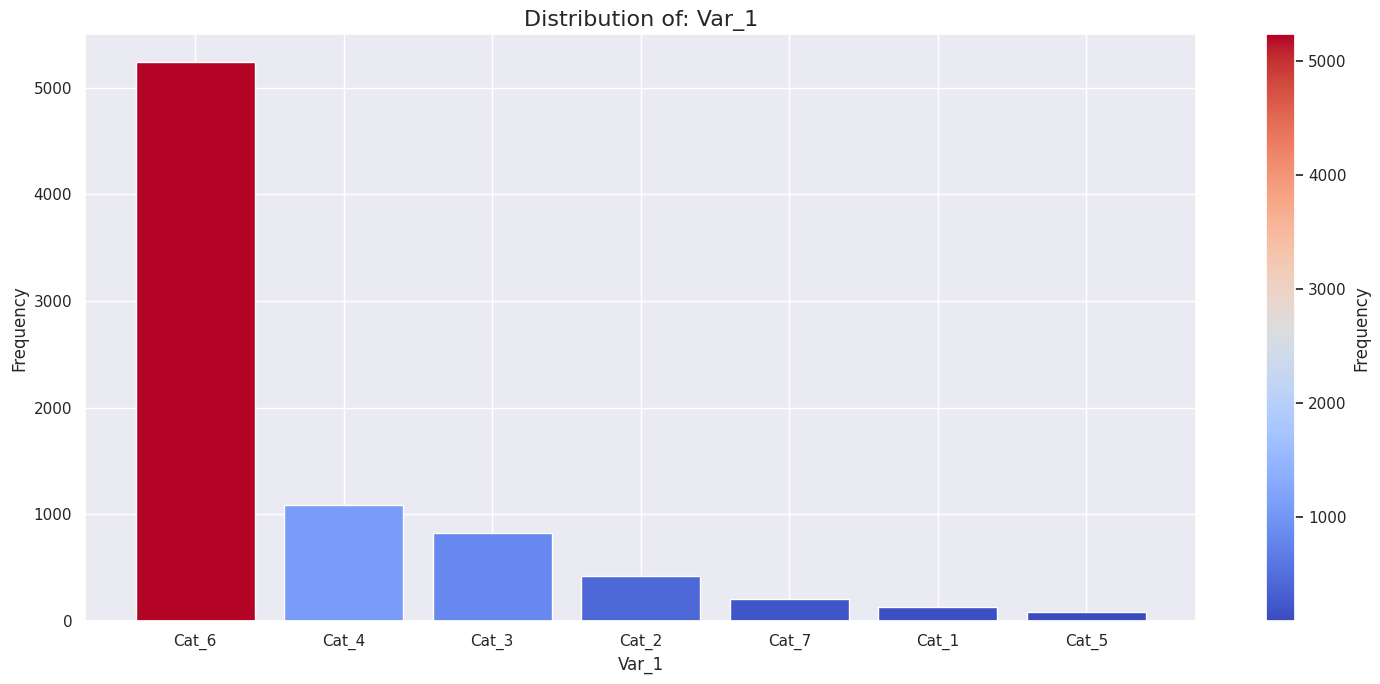

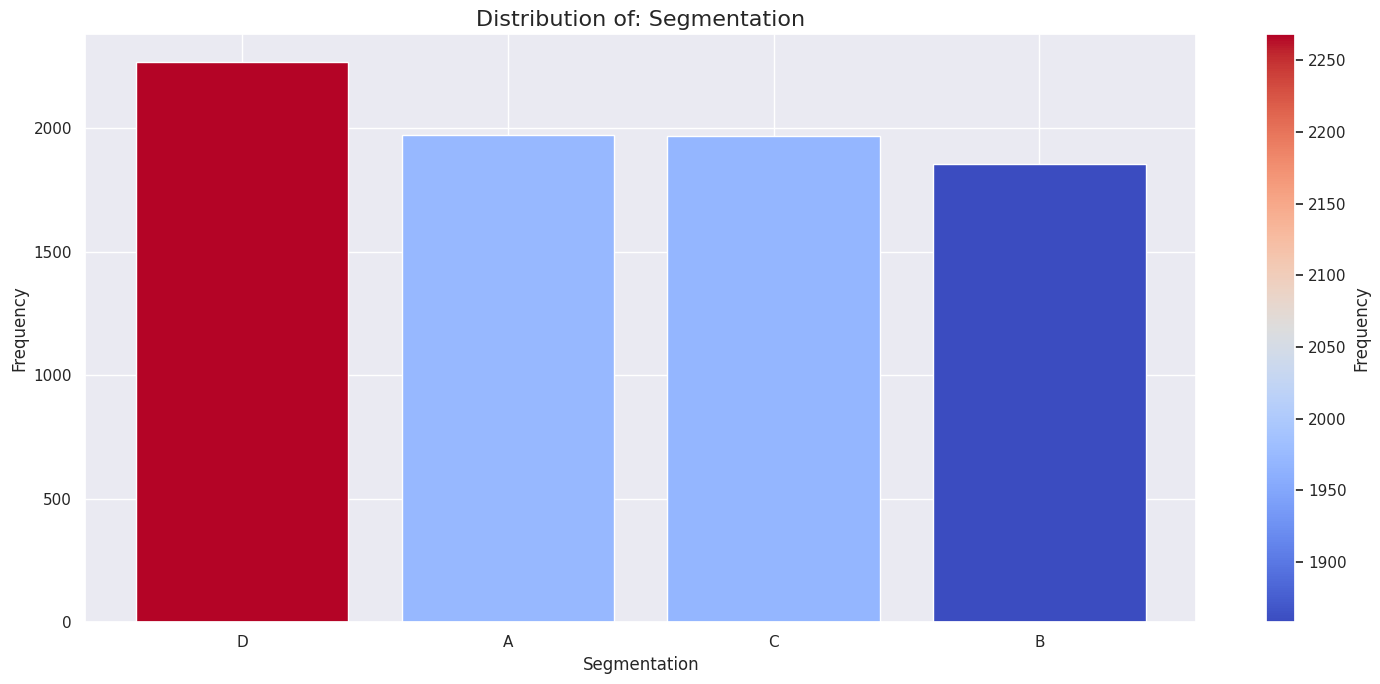

In [ ]:
# For each column, plot the bar chart with colors based on frequency
for col in train_data.columns:
    fig, ax = plt.subplots(figsize=(15, 7))

    # Get the value counts for the current column and sort them from highest to lowest
    value_counts = train_data[col].value_counts().sort_values(ascending=False)

    # Create a color map that will assign colors based on the bar heights
    # Using a red-to-blue colormap where red represents highest frequencies
    norm = plt.Normalize(value_counts.values.min(), value_counts.values.max())
    colors = plt.cm.coolwarm(norm(value_counts.values))

    # Create a barplot using the sorted values and the color mapping
    ax.bar(x=value_counts.index.astype(str), height=value_counts.values, color=colors)

    # Set the title dynamically
    ax.set_title(f'Distribution of: {col}', fontsize=16)

    # Add labels
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

    # Rotate x-ticks if the number of unique values is greater than or equal to 9
    if len(value_counts) >= 9:
        plt.setp(ax.get_xticklabels(), rotation=90)

    # Add a colorbar to show the frequency scale
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('Frequency', fontsize=12)

    plt.tight_layout()
    plt.show()

In [ ]:
data.head(20)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4
1,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4
2,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6
3,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6
4,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6
5,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6
6,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6
7,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6
8,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7
9,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6


# **Data Preprocessing**

In [ ]:
# เลือกเฉพาะคอลัมน์ที่ต้องการแปลง
cols_to_encode = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]

# กำหนดลำดับของค่าที่จะเข้ารหัส
categories = [
    ["Female", "Male"],  # Gender: Female = 0, Male = 1
    ["No", "Yes"],  # Ever_Married: No = 0, Yes = 1
    ["No", "Yes"],  # Graduated: No = 0, Yes = 1
    sorted(data["Profession"].unique()),  # Profession: เรียงค่าที่มีอยู่จริง
    ["Low", "Average", "High"],  # Spending_Score: Low = 0, Average = 1, High = 2
    sorted(data["Var_1"].unique())  # Var_1: เรียงค่าที่มีอยู่จริง
]

# ใช้ OrdinalEncoder เฉพาะกับคอลัมน์ที่เลือก
OE = OrdinalEncoder(categories=categories)
encoded_cols = pd.DataFrame(OE.fit_transform(data[cols_to_encode]), columns=cols_to_encode)

# แปลงค่าที่ได้จาก float → int
encoded_cols = encoded_cols.astype(int)

# รวมคอลัมน์ที่เข้ารหัสแล้วกลับเข้ากับ DataFrame เดิม
data[cols_to_encode] = encoded_cols

In [ ]:
data.head(20)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,1,0,22,0,5,1.0,0,4.0,3
1,0,1,38,1,2,1.0,1,3.0,3
2,0,1,67,1,2,1.0,0,1.0,5
3,1,1,67,1,7,0.0,2,2.0,5
4,0,1,40,1,3,1.0,2,6.0,5
5,1,1,56,0,0,0.0,1,2.0,5
6,1,0,32,1,5,1.0,0,3.0,5
7,0,0,33,1,5,1.0,0,3.0,5
8,0,1,61,1,2,0.0,0,3.0,6
9,0,1,55,1,0,1.0,1,4.0,5


In [ ]:
data.isna().sum() #checking missing values

,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


<Axes: >

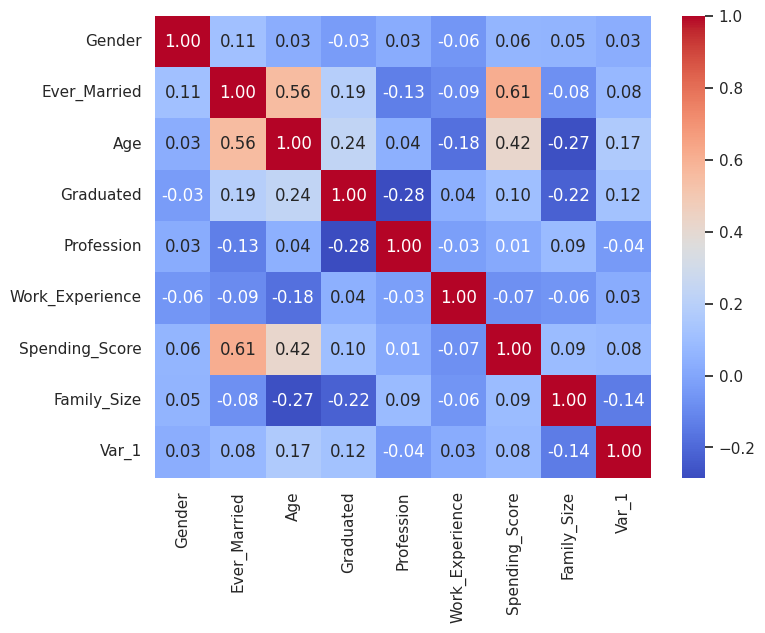

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

# **Segmentation Using K-means Clustering**

In [ ]:
inertia = []

for i in range(1,11):
    kmean = KMeans(n_clusters=i).fit(data)
    inertia.append(kmean.inertia_)

In [ ]:
inertia

[2435732.918567174,
 891739.1160889497,
 504135.4146048603,
 351753.1173175855,
 307242.8446986194,
 246716.64121239126,
 231457.57676780704,
 192110.43714244748,
 170429.6171499373,
 161155.70543669094]

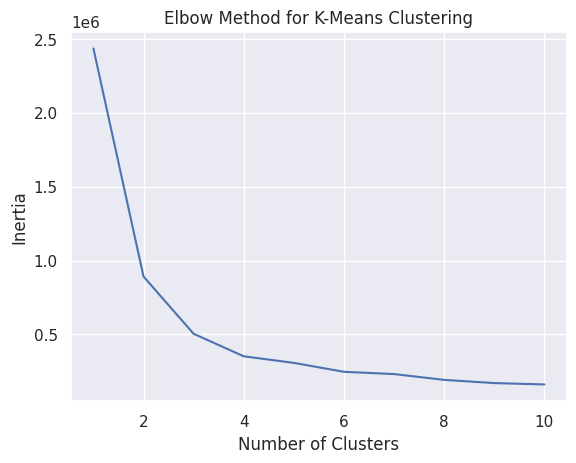

In [ ]:
# line plot for inertia to find the n_cluster value
sns.lineplot(x=range(1, 11), y=inertia, markers='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means Clustering')
plt.grid(True)
plt.show()

In [ ]:
# prompt: Silhouette Score k=2  k=4

from sklearn.metrics import silhouette_score

# KMeans with k=2
kmeans_2 = KMeans(n_clusters=2, random_state=42)
kmeans_2.fit(data)
silhouette_avg_2 = silhouette_score(data, kmeans_2.labels_)
print(f"Silhouette score for k=2: {silhouette_avg_2}")

# KMeans with k=2
kmeans_2 = KMeans(n_clusters=3, random_state=42)
kmeans_2.fit(data)
silhouette_avg_2 = silhouette_score(data, kmeans_2.labels_)
print(f"Silhouette score for k=3: {silhouette_avg_2}")

# KMeans with k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42)
kmeans_4.fit(data)
silhouette_avg_4 = silhouette_score(data, kmeans_4.labels_)
print(f"Silhouette score for k=4: {silhouette_avg_4}")


Silhouette score for k=2: 0.5275179909986261
Silhouette score for k=3: 0.44707414028538955
Silhouette score for k=4: 0.40049161153479923


In [ ]:
# Assign cluster labels to data using KMeans (n_clusters=4)

kmean=KMeans(n_clusters=4).fit(data)
kmean.labels_

array([1, 2, 3, ..., 1, 1, 2], dtype=int32)

In [ ]:
segmented_data = data.copy()
segmented_data['cluster'] = kmean.labels_

In [ ]:
segmented_data.head(20)

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,cluster
0,1,0,22,0,5,1.0,0,4.0,3,1
1,0,1,38,1,2,1.0,1,3.0,3,2
2,0,1,67,1,2,1.0,0,1.0,5,3
3,1,1,67,1,7,0.0,2,2.0,5,3
4,0,1,40,1,3,1.0,2,6.0,5,2
5,1,1,56,0,0,0.0,1,2.0,5,0
6,1,0,32,1,5,1.0,0,3.0,5,1
7,0,0,33,1,5,1.0,0,3.0,5,1
8,0,1,61,1,2,0.0,0,3.0,6,0
9,0,1,55,1,0,1.0,1,4.0,5,0


In [ ]:
segmented_data['cluster'].value_counts()

,count
cluster,
1,2681
2,2523
0,1812
3,1052


In [ ]:
mapping = {2: 'A', 3: 'B', 1: 'D', 0: 'C'}
segmented_data['cluster'] = segmented_data['cluster'].map(mapping)
segmented_data.head(20)


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,cluster
0,1,0,22,0,5,1.0,0,4.0,3,D
1,0,1,38,1,2,1.0,1,3.0,3,A
2,0,1,67,1,2,1.0,0,1.0,5,B
3,1,1,67,1,7,0.0,2,2.0,5,B
4,0,1,40,1,3,1.0,2,6.0,5,A
5,1,1,56,0,0,0.0,1,2.0,5,C
6,1,0,32,1,5,1.0,0,3.0,5,D
7,0,0,33,1,5,1.0,0,3.0,5,D
8,0,1,61,1,2,0.0,0,3.0,6,C
9,0,1,55,1,0,1.0,1,4.0,5,C


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Separate features and target variable
X = segmented_data.drop('cluster', axis=1)
y = segmented_data['cluster']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=4)

# Train the classifier
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9919454770755886
              precision    recall  f1-score   support

           A       0.98      1.00      0.99       522
           B       1.00      1.00      1.00       206
           C       0.99      0.97      0.98       345
           D       1.00      1.00      1.00       541

    accuracy                           0.99      1614
   macro avg       0.99      0.99      0.99      1614
weighted avg       0.99      0.99      0.99      1614



In [ ]:
train_data['predicted_segment'] = segmented_data['cluster'].values
train_data['Segmentation'] = train_data['Segmentation'].astype(str)
train_data['predicted_segment'] = train_data['predicted_segment'].astype(str)

In [ ]:
print(train_data[['Segmentation', 'predicted_segment']].head(20))


   Segmentation predicted_segment
0             D                 D
1             A                 A
2             B                 B
3             B                 B
4             A                 A
5             C                 C
6             C                 D
7             D                 D
8             D                 C
9             C                 C
10            A                 D
11            D                 D
12            D                 D
13            A                 B
14            B                 C
15            C                 A
16            D                 D
17            B                 D
18            B                 C
19            C                 B


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(train_data['Segmentation'], train_data['predicted_segment'])
print(f"✅ Accuracy of the model: {accuracy:.4f}")


✅ Accuracy of the model: 0.4217


In [ ]:
from sklearn.cluster import AgglomerativeClustering
# Agglomerative Clustering with k=4
agg_clustering = AgglomerativeClustering(n_clusters=4)
agg_clustering.fit(data)

# Assign cluster labels
segmented_data_agg = data.copy()
segmented_data_agg['cluster'] = agg_clustering.labels_

# Map cluster labels to match the original segmentation (A, B, C, D)
mapping_agg = {2: 'A', 3: 'B', 1: 'D', 0: 'C'}
segmented_data_agg['cluster'] = segmented_data_agg['cluster'].map(mapping_agg)


train_data['predicted_segment_agg'] = segmented_data_agg['cluster'].values
train_data['predicted_segment_agg'] = train_data['predicted_segment_agg'].astype(str)

accuracy_agg = accuracy_score(train_data['Segmentation'], train_data['predicted_segment_agg'])
print(f"✅ Accuracy of Agglomerative Clustering model: {accuracy_agg:.4f}")


✅ Accuracy of Agglomerative Clustering model: 0.2231


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import accuracy_score
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=3) # Adjust eps and min_samples as needed
dbscan.fit(data)

# Assign cluster labels
segmented_data_dbscan = data.copy()
segmented_data_dbscan['cluster'] = dbscan.labels_

# Handle Noise Points (-1 labels) - Replace with the most frequent cluster
most_frequent_cluster = segmented_data_dbscan['cluster'].value_counts().index[0]
segmented_data_dbscan['cluster'] = segmented_data_dbscan['cluster'].replace(-1, most_frequent_cluster)

mapping_agg = {2: 'A', 3: 'B', 1: 'D', 0: 'C'} # Example mapping - adjust as necessary
segmented_data_agg['cluster'] = segmented_data_dbscan['cluster'].map(mapping_agg)
# This mapping needs careful consideration depending on your DBSCAN result
# You can use a visualization tool to help understand the cluster assignments and improve the mapping
unique_clusters = segmented_data_dbscan['cluster'].unique()

if len(unique_clusters) < 4 :
  print('DBSCAN algorithm does not form 4 clusters, please adjust the eps, min_samples parameter')
  print('Current number of clusters formed: ',len(unique_clusters))

else:
  mapping_dbscan = {cluster: chr(ord('A') + i) for i, cluster in enumerate(unique_clusters[:4])}
  segmented_data_dbscan['cluster'] = segmented_data_dbscan['cluster'].map(mapping_dbscan)


  train_data['predicted_segment_dbscan'] = segmented_data_dbscan['cluster'].values
  train_data['predicted_segment_dbscan'] = train_data['predicted_segment_dbscan'].astype(str)

  accuracy_dbscan = accuracy_score(train_data['Segmentation'], train_data['predicted_segment_dbscan'])
  print(f"✅ Accuracy of DBSCAN model: {accuracy_dbscan:.4f}")


✅ Accuracy of DBSCAN model: 0.2312


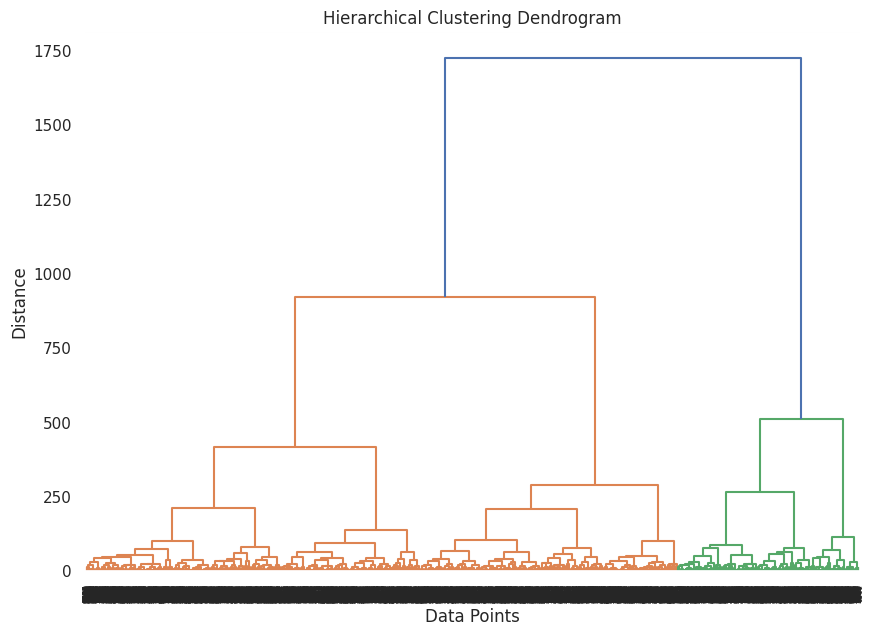

✅ Accuracy of Hierarchical Clustering model: 0.2231


In [ ]:
import matplotlib.pyplot as plt
# Hierarchical Clustering (Dendrogram)
linked = linkage(data, 'ward') # Use ward linkage method

plt.figure(figsize=(10, 7))
dendrogram(linked,
            orientation='top',
            distance_sort='descending',
            show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# Hierarchical Clustering with a specific number of clusters (e.g., 4)
hierarchical_clustering = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hierarchical_clustering.fit(data)

# Assign cluster labels
segmented_data_hierarchical = data.copy()
segmented_data_hierarchical['cluster'] = hierarchical_clustering.labels_

# Map cluster labels to match the original segmentation (A, B, C, D)
mapping_hierarchical = {2: 'A', 3: 'B', 1: 'D', 0: 'C'}
segmented_data_hierarchical['cluster'] = segmented_data_hierarchical['cluster'].map(mapping_hierarchical)

train_data['predicted_segment_hierarchical'] = segmented_data_hierarchical['cluster'].values
train_data['predicted_segment_hierarchical'] = train_data['predicted_segment_hierarchical'].astype(str)

accuracy_hierarchical = accuracy_score(train_data['Segmentation'], train_data['predicted_segment_hierarchical'])
print(f"✅ Accuracy of Hierarchical Clustering model: {accuracy_hierarchical:.4f}")


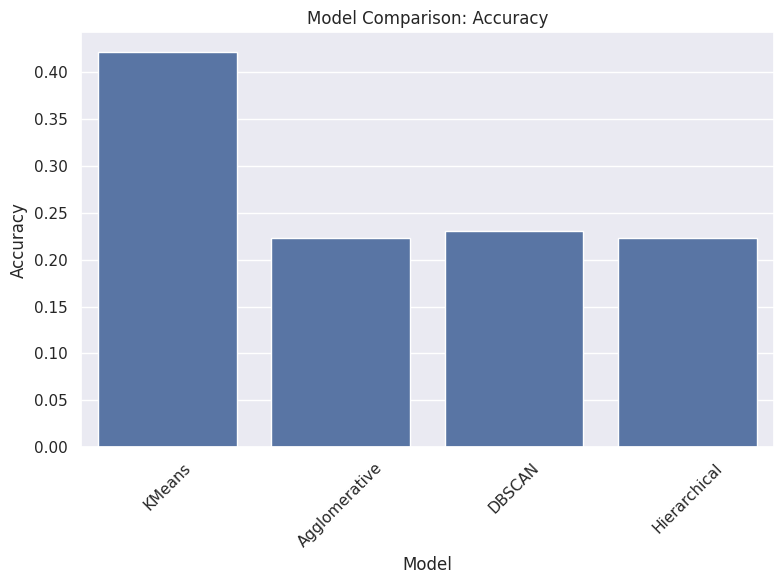

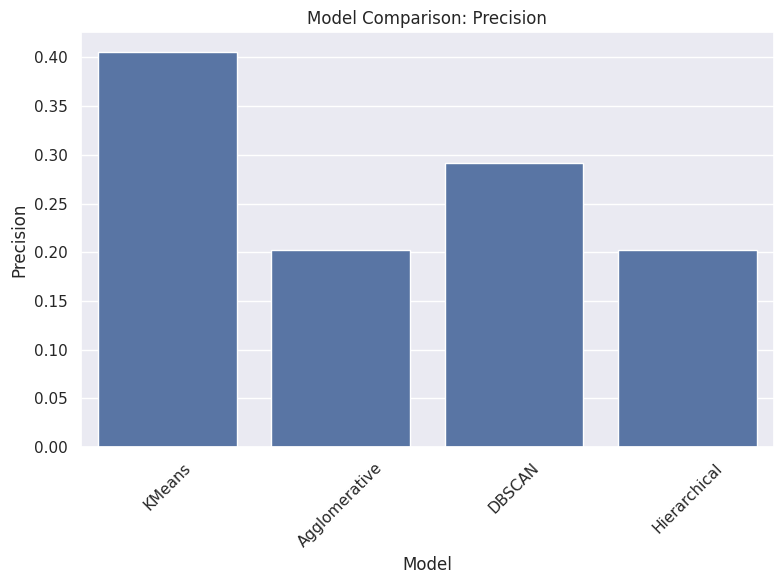

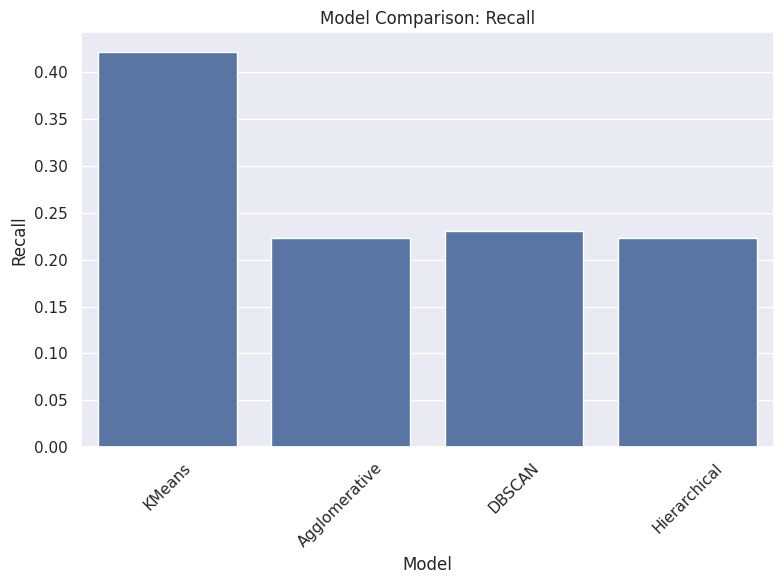

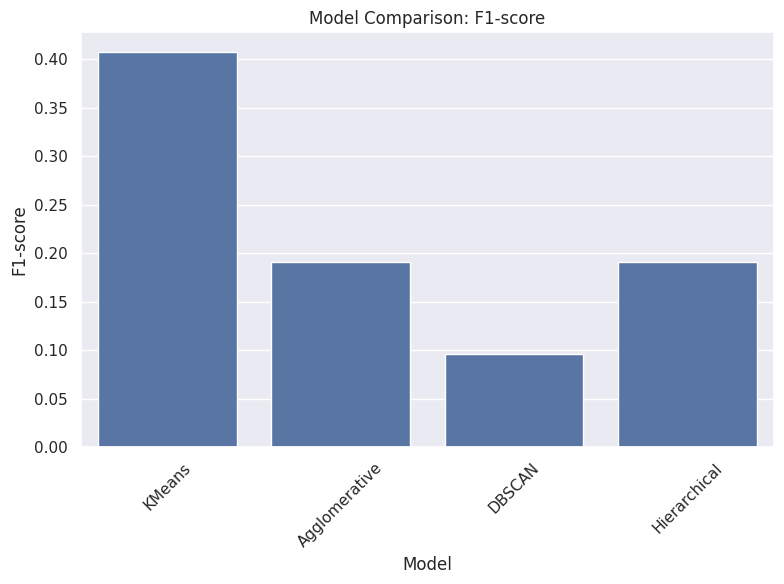

,Model,Accuracy,Precision,Recall,F1-score
0,KMeans,0.421666,0.405497,0.421666,0.407098
1,Agglomerative,0.223104,0.202692,0.223104,0.190930
2,DBSCAN,0.231160,0.291886,0.231160,0.096140
3,Hierarchical,0.223104,0.202692,0.223104,0.190930


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    'KMeans': 'predicted_segment',
    'Agglomerative': 'predicted_segment_agg',
    'DBSCAN': 'predicted_segment_dbscan',
    'Hierarchical': 'predicted_segment_hierarchical'
}

results = []
for model_name, prediction_col in models.items():
    accuracy = accuracy_score(train_data['Segmentation'], train_data[prediction_col])
    precision = precision_score(train_data['Segmentation'], train_data[prediction_col], average='weighted')
    recall = recall_score(train_data['Segmentation'], train_data[prediction_col], average='weighted')
    f1 = f1_score(train_data['Segmentation'], train_data[prediction_col], average='weighted')
    results.append([model_name, accuracy, precision, recall, f1])

# สร้าง DataFrame สำหรับเก็บผลลัพธ์
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])

# วาดกราฟเปรียบเทียบ
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
for metric in metrics:
    plt.figure(figsize=(8, 6))
    sns.barplot(x='Model', y=metric, data=results_df)
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.title(f'Model Comparison: {metric}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# แสดงตารางผลลัพธ์
display(results_df)